In [1]:
import numpy as np
import librosa
import soundfile as sf
import torch
import matplotlib.pyplot as plt
from main import init
import os
import torchaudio
from data import *
from main import *
from generate import adpcm_encode, adpcm_decode

/mnt/nvme0/home/utbt/KhoaVM/npp_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def change_length(x):
        max_length = 1048064
        n = x.shape[0]

        if n > max_length:
            x = x[:max_length]
        
        elif n < max_length:
            pad_size = max_length - n
            return np.pad(array=x, pad_width=(0, pad_size), mode='constant', constant_values=0)
        
        return x

def spec_to_audio(spec_db, n_fft=1022, hop_length=512):
    spec = librosa.db_to_amplitude(spec_db)

    audio = librosa.griffinlim(
        spec,
        n_fft=n_fft,
        hop_length=hop_length,
        n_iter=256,
    )

    return audio


def to_spec(x):
    spec = librosa.amplitude_to_db(np.abs(librosa.stft(x, n_fft=1022, hop_length=512)))
    return spec

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [4]:
x_path = '/mnt/nvme0/home/utbt/KhoaVM/z_Neural_Post_Processing/data/IRMAS/degraded_wav/test/(02) dont kill the whale-1.wav'
y_path = '/mnt/nvme0/home/utbt/KhoaVM/z_Neural_Post_Processing/data/IRMAS/wav/test/(02) dont kill the whale-1.wav'

In [5]:
x_waveform, sr = librosa.load(x_path, sr=64000)
y_waveform, sr = librosa.load(y_path, sr=64000)

x_waveform = change_length(x_waveform)
y_waveform = change_length(y_waveform)

In [6]:
x_spec = torch.tensor(to_spec(x_waveform)).unsqueeze(0).unsqueeze(0).to(device)
y_spec = to_spec(y_waveform)

In [7]:
models = [Autoencoder().to(device), Unet().to(device), smp.UnetPlusPlus(encoder_name="vgg11_bn", encoder_depth=5, activation=None, in_channels=1, classes=1).to(device), \
          AttU_Net(img_ch=1, output_ch=1).to(device), Proposed(img_ch=1, output_ch=1).to(device)]

checkpoints = ['./checkpoints/IRMAS_checkpoints/IRMAS_Autoencoder.pth', './checkpoints/IRMAS_checkpoints/IRMAS_Unet.pth', './checkpoints/IRMAS_checkpoints/IRMAS_UnetPlusPlus.pth', \
               './checkpoints/IRMAS_checkpoints/IRMAS_UnetAttention.pth', './checkpoints/IRMAS_checkpoints/IRMAS_Proposed.pth']


outputs_spec = []

for model, checkpoint in zip(models, checkpoints):
    model.load_state_dict(torch.load(checkpoint))
    model.eval()
    with torch.no_grad():
        outputs_spec.append(model(x_spec))

/tmp/ipykernel_299251/1436903595.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(checkpoint))


In [8]:
x_spec = x_spec.cpu().detach().numpy().squeeze()

In [9]:
x_waveform = spec_to_audio(x_spec)
y_waveform = spec_to_audio(y_spec)

In [10]:
outputs_waveform = []

for output in outputs_spec:
    output = output.cpu().detach().numpy().squeeze()
    outputs_waveform.append(spec_to_audio(output))

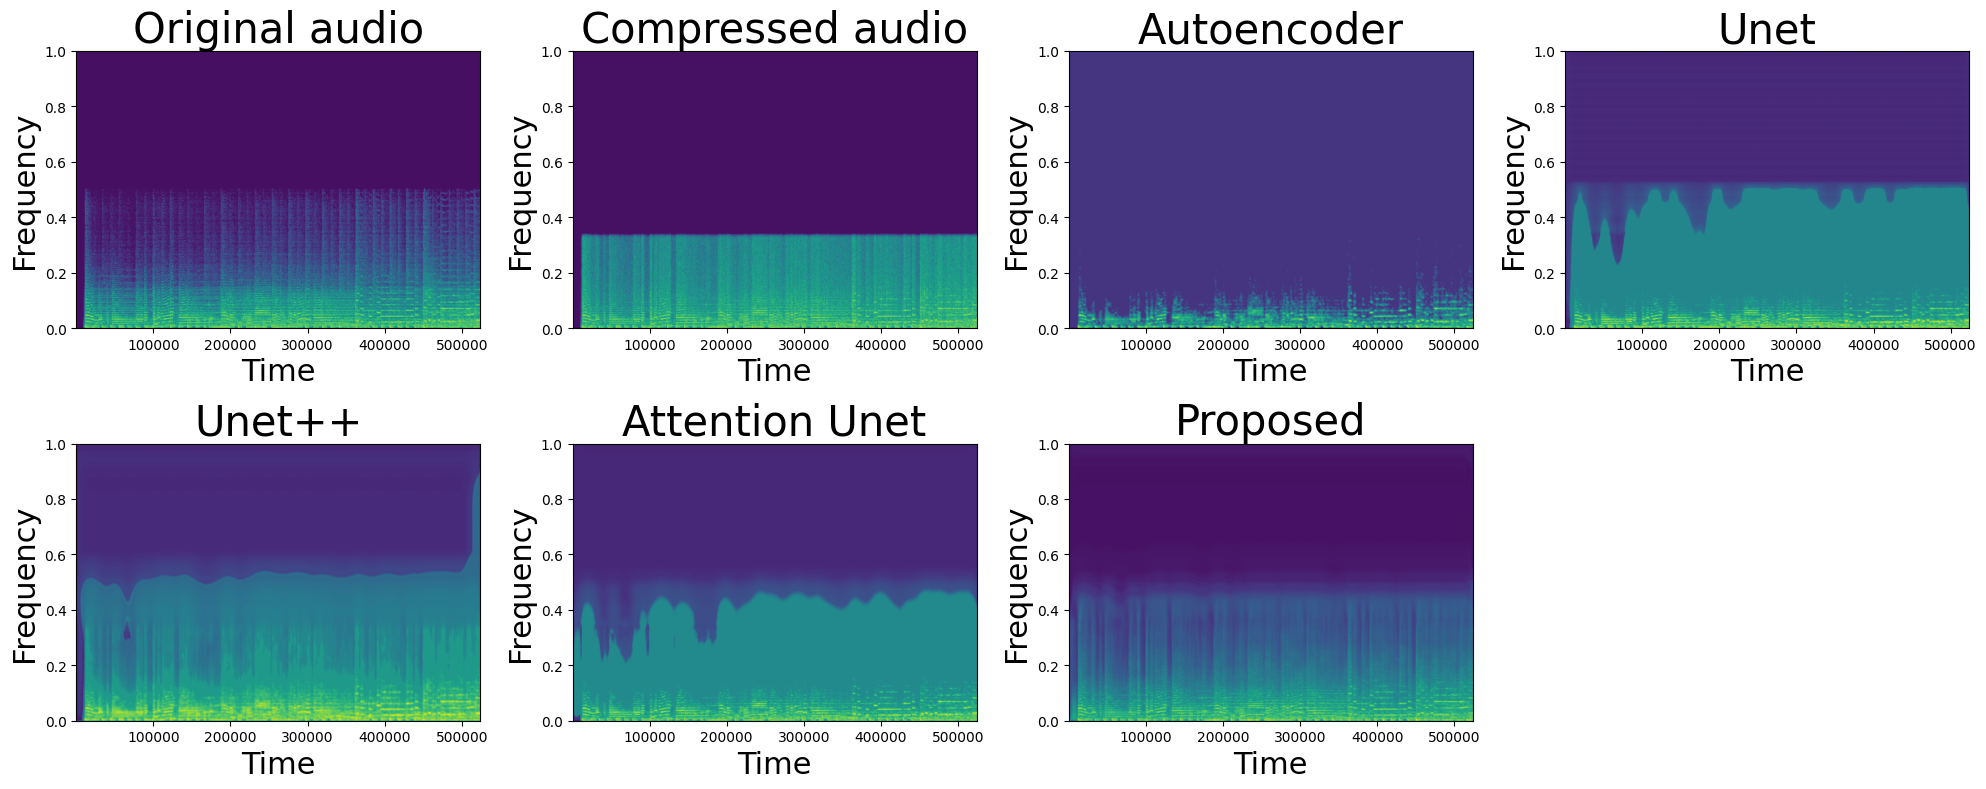

: 

In [ ]:
import math
NFFT = 1022
hop_length = 512
noverlap = NFFT - hop_length  

waveforms = [y_waveform, x_waveform] + outputs_waveform

titles = [
    "Original audio",
    "Compressed audio",
    "Autoencoder",
    "Unet",
    "Unet++",
    "Attention Unet",
    "Proposed"
]

n = len(waveforms)
cols = 4
rows = math.ceil(n / cols)

plt.figure(figsize=(20, 8))  # tăng chiều cao

for i, (wav, title) in enumerate(zip(waveforms, titles)):
    plt.subplot(rows, cols, i+1)
    
    Pxx, freqs, bins, im = plt.specgram(
        wav,
        NFFT=NFFT,
        noverlap=noverlap,
    )
    
    plt.title(title, fontsize=30)
    plt.xlabel("Time", fontsize=22)
    plt.ylabel("Frequency", fontsize=22)

plt.tight_layout()
plt.show()